In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import  roc_auc_score


In [3]:
X_train = pd.read_pickle('../datos/entrenamiento/X_train.pkl')
X_test = pd.read_pickle('../datos/entrenamiento/X_test.pkl')
y_train = pd.read_pickle('../datos/entrenamiento/y_train.pkl')
y_test = pd.read_pickle('../datos/entrenamiento/y_test.pkl')


In [4]:

dcs = DecisionTreeClassifier(max_depth=5, random_state=42)

dcs.fit(X_train, y_train)
y_pred = dcs.predict_proba(X_test)

print(y_pred)
print('ROC AUC: ', roc_auc_score(y_test, y_pred[:, 1]))

[[0.93964997 0.06035003]
 [0.89524207 0.10475793]
 [0.93964997 0.06035003]
 ...
 [0.93964997 0.06035003]
 [0.93964997 0.06035003]
 [0.93964997 0.06035003]]
ROC AUC:  0.881108071544777


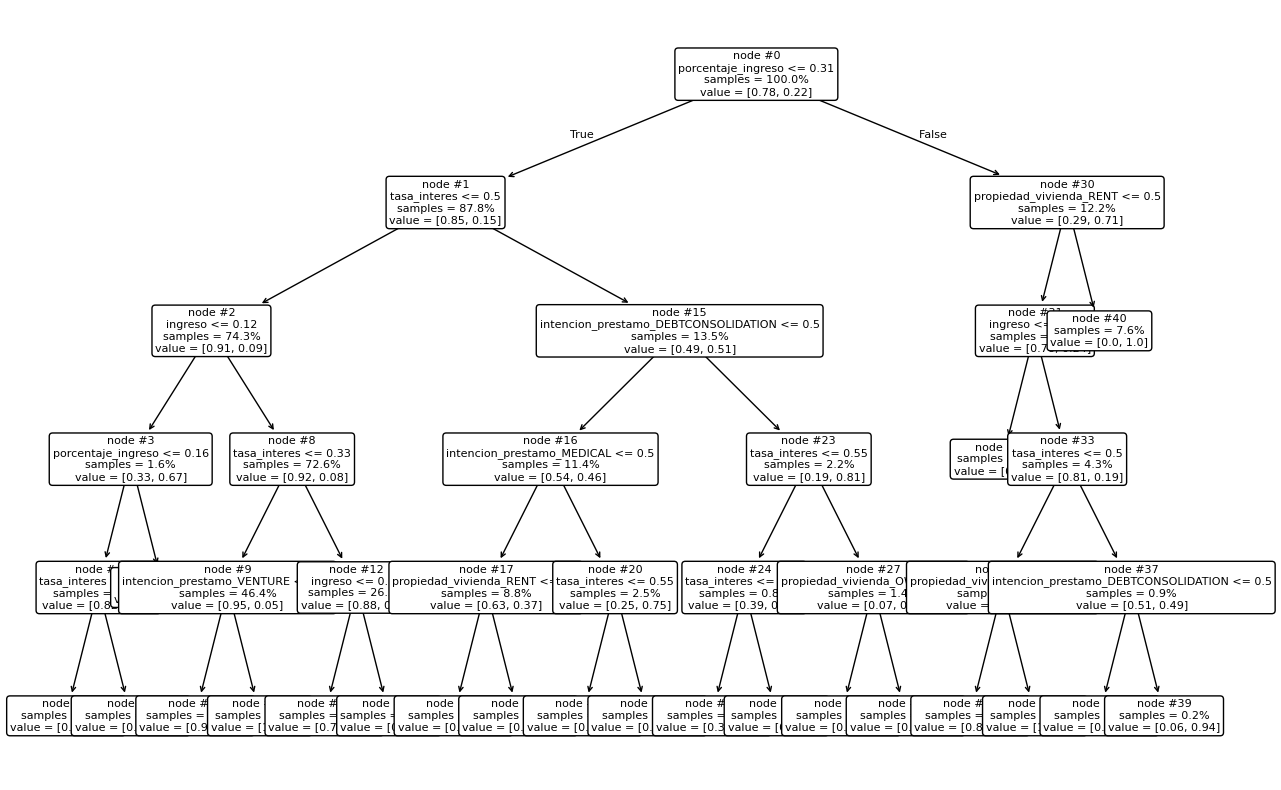

In [5]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(dcs,
          feature_names=X_test.columns,
          impurity=False,
          node_ids=True,
          proportion=True,
          rounded=True,
          precision=2,
          fontsize=8)  # Cambia el tamaño aquí
plt.show();

In [6]:
alphas = dcs.cost_complexity_pruning_path(X_train,y_train)['ccp_alphas']
alphas

array([0.        , 0.00019845, 0.00030936, 0.00046391, 0.00049273,
       0.00059305, 0.00074813, 0.00076123, 0.00093911, 0.00099507,
       0.00179892, 0.00193387, 0.00324701, 0.00517583, 0.00525064,
       0.01133254, 0.03329458, 0.04122159, 0.06659875])

In [7]:
arboles = []

for alpha in alphas:
    arbol = DecisionTreeClassifier(ccp_alpha=alpha)
    arbol.fit(X_train, y_train)
    arboles.append(arbol)

arboles

[DecisionTreeClassifier(ccp_alpha=np.float64(0.0)),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.00019844932112478633)),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.00030935810378572137)),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.0004639059370580086)),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.0004927260604292993)),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.0005930513298722537)),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.0007481322632431047)),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.0007612306099778702)),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.0009391085293035881)),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.0009950661021696002)),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.0017989184359426397)),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.0019338681169924921)),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.0032470092951029095)),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.005175832977143337)),
 DecisionTreeClassifier(ccp_alpha=np.

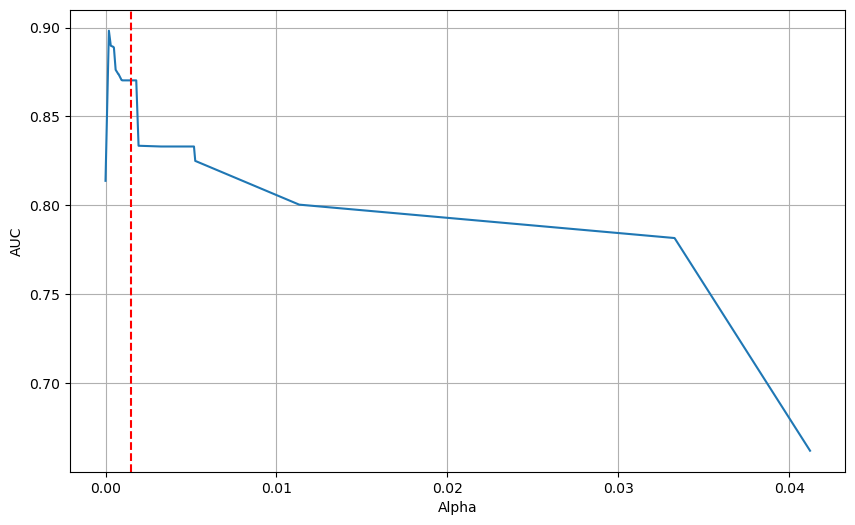

In [8]:
from sklearn.metrics import roc_auc_score

valores_auc = [roc_auc_score(y_test, arbol.predict_proba(X_test)[:, 1]) for arbol in arboles]
#([:, 1]) contiene las probabilidades de que la muestra pertenezca a la clase 1 (la clase positiva)

plt.figure(figsize=(10,  6))
plt.grid()
plt.plot(alphas[:-1], valores_auc[:-1])
plt.axvline(x=0.0015, color='r', linestyle='--')
plt.xlabel("Alpha")
plt.ylabel("AUC")
plt.show();

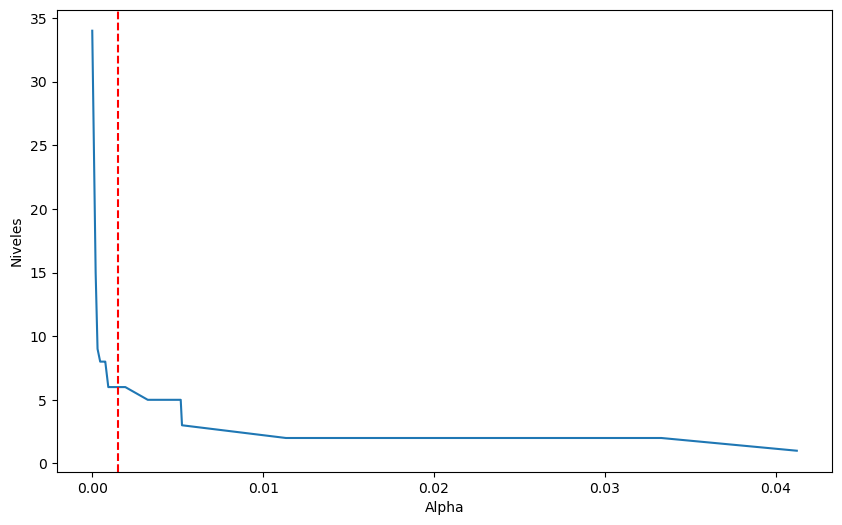

In [9]:
niveles = [arbol.tree_.max_depth for arbol in arboles]
plt.figure(figsize=(10,  6))
plt.plot(alphas[:-1], niveles[:-1])
plt.axvline(x=0.0015, color='r', linestyle='--')
plt.xlabel("Alpha")
plt.ylabel("Niveles")
plt.show();

In [10]:
ac = DecisionTreeClassifier(ccp_alpha=0.0015, random_state=42)

ac.fit(X_train, y_train)

pred = ac.predict_proba(X_test)[:,1]

roc_auc_score(y_test, pred)

0.8702659344934084

In [11]:
ac.get_params()

{'ccp_alpha': 0.0015,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

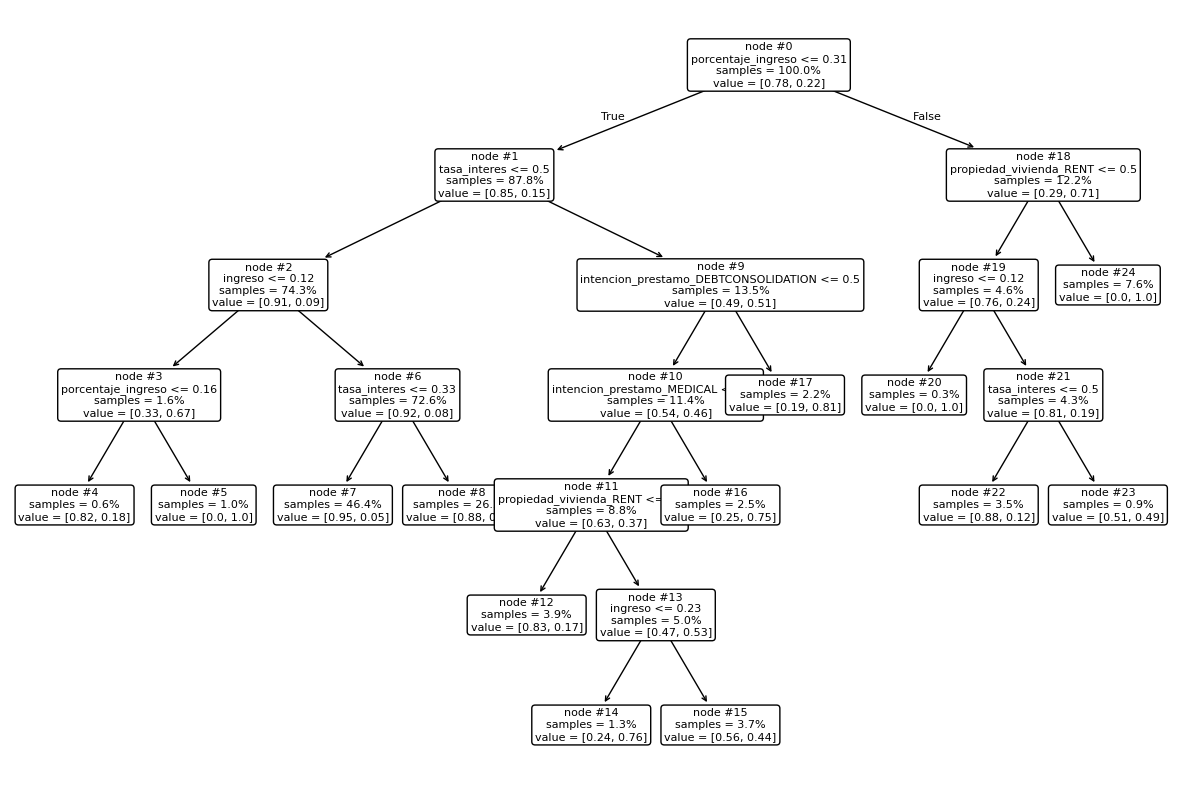

In [12]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(ac,
          feature_names=X_test.columns,
          impurity=False,
          node_ids=True,
          proportion=True,
          rounded=True,
          precision=2,
          fontsize=8)  # Cambia el tamaño aquí
plt.show();

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metricas_cv = cross_val_score(estimator=ac, 
                              X=X_train, 
                              y=y_train, 
                              cv=skf, 
                              scoring='roc_auc')
print("ROC AUC Score (Cross-Validation):", metricas_cv.mean())

ROC AUC Score (Cross-Validation): [0.86793684 0.85150111 0.86445863 0.89080781 0.86680498]
